## Goal: Find the 'peak' hours of demand for Med Center Express

### Background:

With the opening of the new University Hospital tower, there has been some issues with capacity at various times on med center express. Ultimately approximately 20,000 more riders are present on the med center express loop and demand may have moved times with new shifts in the tower. 

### Notes:
- The 9am hour (which is post current peak morning service) has had overcrowding
- In previous analysis it has been found that the ~3pm hour has been identified as an overly crowded time.
- This analysis is done with data subset from 4/1/2026 - 4/15/2026
- This is limited by accuracy of the APCs
- No data exists for people 'waiting' for a bus to my knowledge
- This is descriptive of past events and does not necessarily predict future patterns


In [9]:
# original data (4/1/2026 - 4/15/2026) is additionally stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
import sys
import os

# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd

apr_mc_df = mcd.process_mc_busstate(year="2026", month="APR")

apr_mc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18560 entries, 0 to 18559
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   BUS_ID      18560 non-null  int64          
 1   DATE        18560 non-null  datetime64[us] 
 2   COUNT       18560 non-null  int64          
 3   STOP_ID     18560 non-null  int64          
 4   BOARDINGS   18560 non-null  int64          
 5   ALIGHTINGS  18560 non-null  int64          
 6   LOAD        18560 non-null  int64          
 7   RUN_ID      18560 non-null  float64        
 8   DEST        18560 non-null  str            
 9   ARRIVAL     18560 non-null  datetime64[us] 
 10  DEPARTURE   18560 non-null  datetime64[us] 
 11  DWELL       18560 non-null  timedelta64[us]
 12  HOUR        18560 non-null  int32          
 13  MINUTE      18560 non-null  int32          
dtypes: datetime64[us](3), float64(1), int32(2), int64(6), str(1), timedelta64[us](1)
memory usage: 1.8 MB


### NOTE:
- Using University Hospital and Doan Hall stops to determine demand
- If carmack lot stops should be included, come back here to edit

In [109]:
# cut down to only doan 37 and UH 401
# should now only have info for UH and Doan stops
uh_doan_apr_mc_df = apr_mc_df[(apr_mc_df['STOP_ID'] == 401) | (apr_mc_df['STOP_ID'] == 37)]

uh_doan_apr_mc_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
4,1303,2026-04-01,5,401,22,2,27,1503.0,MC,1900-01-01 14:06:59,1900-01-01 14:08:18,0 days 00:01:19,14,6
5,1303,2026-04-01,6,37,13,8,32,1503.0,MC,1900-01-01 14:08:51,1900-01-01 14:11:46,0 days 00:02:55,14,8
10,1303,2026-04-01,11,401,11,13,15,1503.0,MC,1900-01-01 14:30:21,1900-01-01 14:32:22,0 days 00:02:01,14,30
11,1303,2026-04-01,12,37,8,7,14,1503.0,MC,1900-01-01 14:32:57,1900-01-01 14:34:21,0 days 00:01:24,14,32
16,1303,2026-04-01,17,401,3,7,5,1503.0,MC,1900-01-01 14:53:41,1900-01-01 14:54:31,0 days 00:00:50,14,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18545,2503,2026-04-14,18536,37,6,1,11,1507.0,MC,1900-01-01 19:08:34,1900-01-01 19:11:40,0 days 00:03:06,19,8
18550,2503,2026-04-14,18541,401,38,2,38,1507.0,MC,1900-01-01 19:28:42,1900-01-01 19:30:23,0 days 00:01:41,19,28
18551,2503,2026-04-14,18542,37,5,1,42,1507.0,MC,1900-01-01 19:30:54,1900-01-01 19:33:39,0 days 00:02:45,19,30
18556,2503,2026-04-14,18547,401,6,1,5,1507.0,MC,1900-01-01 19:49:48,1900-01-01 19:50:46,0 days 00:00:58,19,49


In [11]:
# import visualization libraries
%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [110]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
import pandas as pd

temp = uh_doan_apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))

temp.drop(['ARRIVAL'], axis=1, inplace=True)

# true 30 min buckets to determine peak periods
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

mc_df = temp.copy()

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
mc_df = temp.copy()
mc_df['NET'] = mc_df['BOARDINGS'] - mc_df['ALIGHTINGS'] # net indicates PER STOP

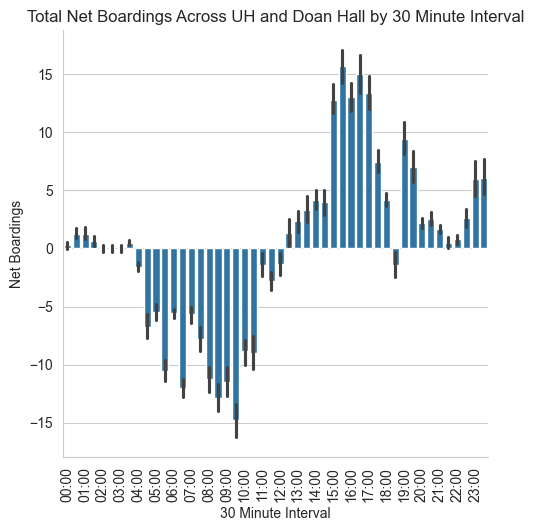

In [111]:
mc_df = mc_df.sort_values(by = "BUCKET")

sns.set_style("whitegrid")
# Plot in chronological order
plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'NET',
    #hue = 'BUCKET',
    kind = 'bar',
    #palette = "viridis"
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval") # Negative indicates passengers inbound, Positive indicates passengers outbound
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

### Notes:
- Clear inbound vs outbound hours
- Inbound appears to peak from approximately 4am - 10am
- Outbound appears to peak from approximately 3pm - 8pm ish

In [112]:
# sort by time bucket and include the avg magnitude
table_df = (
    mc_df # already sorted by time bucket
    .groupby("BUCKET", as_index=False)["NET"].sum() # pos = outbound, neg = inbound
)

table_df

,BUCKET,NET
0,00:00,27
1,00:30,71
2,01:00,35
3,01:30,36
4,02:00,-1
5,02:30,1
6,03:00,0
7,03:30,28
8,04:00,-113
9,04:30,-464


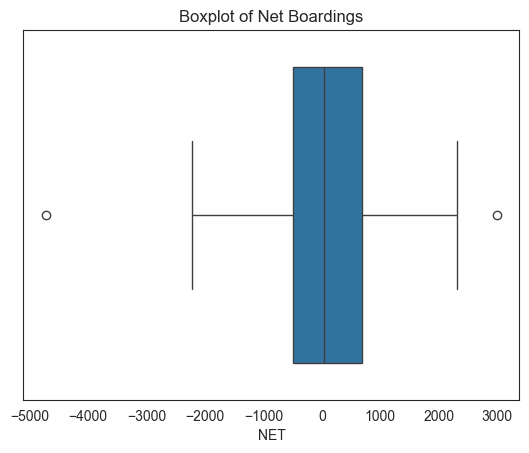

In [113]:
# boxplot both net and avg_magnitude
sns.set_style("white")

sns.boxplot(
    data = table_df,
    x = 'NET'
)
plt.title('Boxplot of Net Boardings')
plt.show()

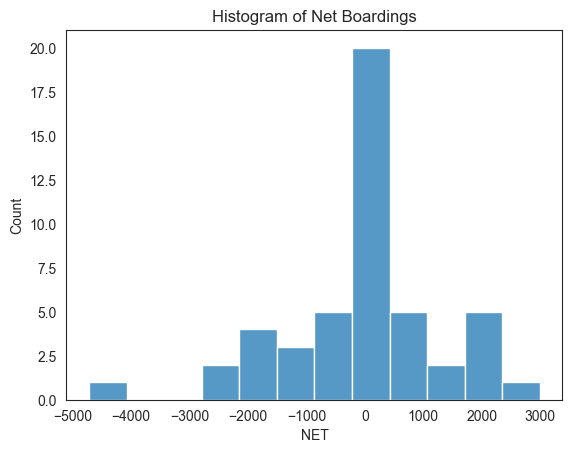

In [114]:
sns.histplot(data=table_df, x='NET')
plt.title('Histogram of Net Boardings')
plt.show()

In [115]:
# Set thresholds
ib_outlier_threshold = -3000
ob_outlier_threshold = 2500

# determine the timeframes in which these outliers occur
outlier_times = table_df[(table_df['NET'] < ib_outlier_threshold) | (table_df['NET'] > ob_outlier_threshold)]
outlier_times

,BUCKET,NET
13,06:30,-4718
31,15:30,2994


### NOTE:
- Based on the boxplots and histograms of the magnitude, there are two clear outliers one for IB and one for OB
- The peak magnitude times are:
    - 6:30am -> inbound
    - 3:30pm -> outbound (less strong)

In [116]:
# Less strict thresholds at the top and bottom quantiles
import numpy as np

# Calculate the top and bottom quantiles
bottom_quantile = np.percentile(table_df['NET'], 25)
top_quantile = np.percentile(table_df['NET'], 75)

print(f'Bottom quantile: {bottom_quantile}, top quantile: {top_quantile}')

# find timeframes within quantiles inclusive
quantile_times = table_df[(table_df['NET'] <= bottom_quantile) | (table_df['NET'] >= top_quantile)]
quantile_times

Bottom quantile: -493.75, top quantile: 681.75


,BUCKET,NET
10,05:00,-583
11,05:30,-1461
12,06:00,-2215
13,06:30,-4718
14,07:00,-1828
15,07:30,-2040
16,08:00,-1837
17,08:30,-2209
18,09:00,-1515
19,09:30,-1137


5am - 10:30am consist of 'peak" inbound hours, 2:30pm - 8pm are 'peak' outbound hours

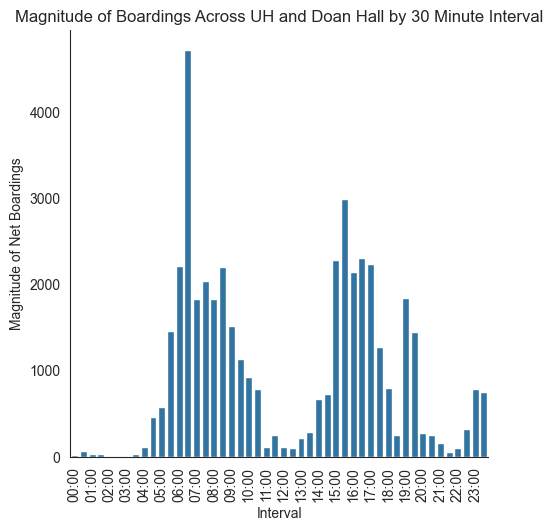

In [117]:
# plot the absolute value of passenger flow through UH/Doan stops
sns.catplot(
    data = table_df,
    x = 'BUCKET',
    y = table_df['NET'].abs(),
    kind = 'bar'
)
plt.title("Magnitude of Boardings Across UH and Doan Hall by 30 Minute Interval") # Negative indicates passengers inbound, Positive indicates passengers outbound
plt.xlabel("Interval")
plt.ylabel("Magnitude of Net Boardings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

From this we can see 2 clear peaks, 1 in morning, and 1 in the evening, as expected.

In [118]:
# remove data from 4/16/2026
mc_df = mc_df[mc_df["DATE"] != "2026-04-16"]

# convert to datetime
work = mc_df.copy()
work["DATE"] = pd.to_datetime(work["DATE"])

# convert to table containing the boarding and alightings at each timeframe across each day
daily_bucket = (
    work.groupby(["DATE", "BUCKET"], as_index=False) # 30 min intervals for each day
        .agg( 
            BOARDINGS=("BOARDINGS", "sum"), # total boardings in 30 min interval across both stops
            ALIGHTINGS=("ALIGHTINGS", "sum"), # total alightings in 30 min interval across both stops
            NET=("NET", "sum") # i guess this is useful for understanding directionality of passenger flow?
        )
)
daily_bucket["ABS_NET"] = daily_bucket["NET"].abs() #abs value
daily_bucket

,DATE,BUCKET,BOARDINGS,ALIGHTINGS,NET,ABS_NET
0,2026-04-01,00:00,5,15,-10,10
1,2026-04-01,00:30,10,0,10,10
2,2026-04-01,01:00,2,0,2,2
3,2026-04-01,01:30,6,2,4,4
4,2026-04-01,02:00,0,0,0,0
...,...,...,...,...,...,...
541,2026-04-15,21:30,15,18,-3,3
542,2026-04-15,22:00,15,7,8,8
543,2026-04-15,22:30,48,11,37,37
544,2026-04-15,23:00,61,3,58,58


In [ ]:
# Grouping the data by 30 min intervals, and taking median of each for a more robust measure of central tendency across the studied timeframe
peak_table = (
    daily_bucket.groupby("BUCKET", as_index=False)
        .agg(
            MED_BOARDINGS=("BOARDINGS", "median"), # median across all days bus ran at each 30 min interval
            #P75_BOARDINGS=("BOARDINGS", lambda s: np.percentile(s, 75)), # 75th percentile across all days bus ran at each 30 min interval
            P90_BOARDINGS=("BOARDINGS", lambda s: np.percentile(s, 90)), # 90th percentile across all days bus ran at each 30 min interval
            MED_ALIGHTINGS=("ALIGHTINGS", "median"),
            P90_ALIGHTINGS=("ALIGHTINGS", lambda s: np.percentile(s, 90)), # 90th percentile across all days bus ran at each 30 min interval
        )
        .sort_values("BUCKET")
)
peak_table

,BUCKET,MED_BOARDINGS,P90_BOARDINGS,MED_ALIGHTINGS,P90_ALIGHTINGS
0,00:00,5.0,7.0,1.0,4.0
1,00:30,5.0,8.8,0.0,0.0
2,01:00,2.0,3.8,0.0,0.0
3,01:30,5.0,6.0,2.0,2.8
4,02:00,0.0,1.8,0.0,1.8
5,02:30,2.0,4.0,2.0,4.0
6,03:00,1.0,3.8,2.0,3.0
7,03:30,2.0,4.8,0.0,1.0
8,04:00,1.0,1.8,10.0,12.8
9,04:30,0.0,1.0,42.0,45.8


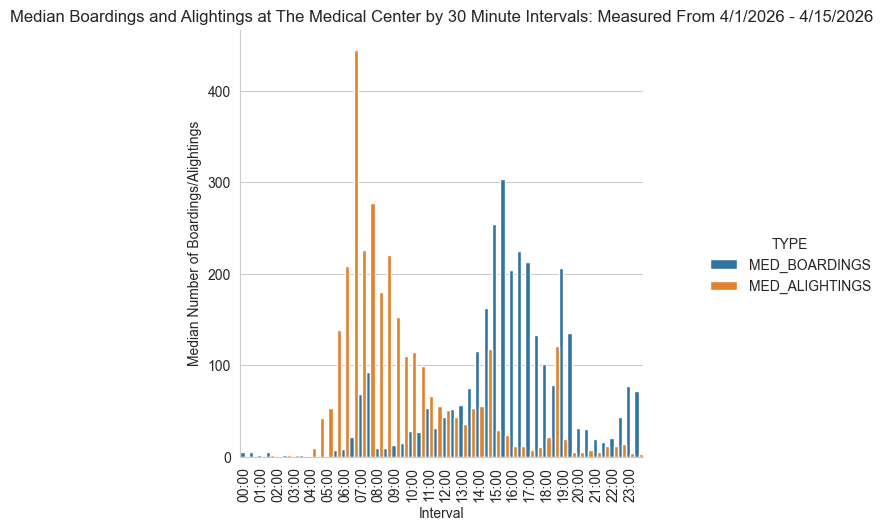

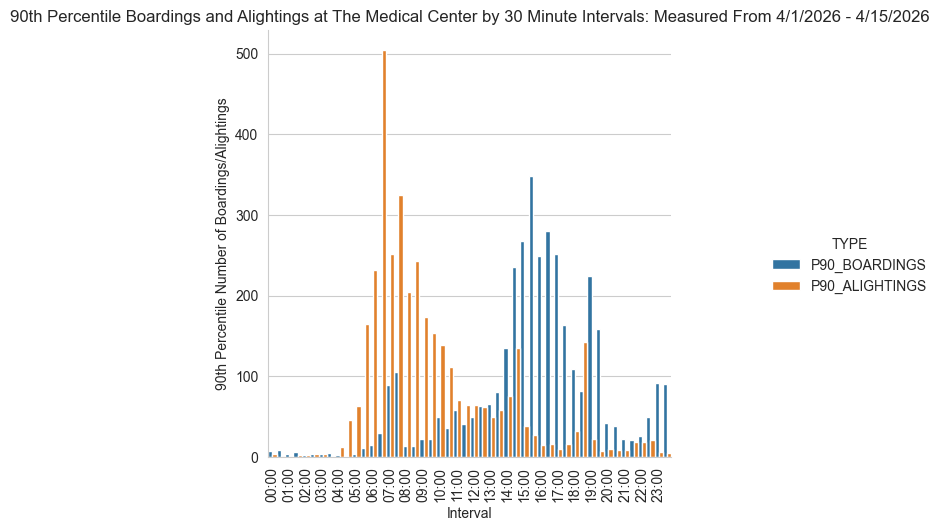

In [143]:
# combine together the med boardings and med alightings to plot these together
sns.set_style("whitegrid")

peak_long = peak_table.melt(
    id_vars="BUCKET",
    value_vars=["MED_BOARDINGS", "MED_ALIGHTINGS"],
    var_name="TYPE",
    value_name="VALUE"
)

sns.catplot(
    data=peak_long,
    x="BUCKET",
    y="VALUE",
    hue="TYPE",
    kind="bar",
    width=1
)

plt.title("Median Boardings and Alightings at The Medical Center by 30 Minute Intervals: Measured From 4/1/2026 - 4/15/2026") # Negative indicates passengers inbound, Positive indicates passengers outbound
plt.xlabel("Interval")
plt.ylabel("Median Number of Boardings/Alightings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

# do the same for the 90th percentile to represent 'worst case scenario'
peak_long_90 = peak_table.melt(
    id_vars="BUCKET",
    value_vars=["P90_BOARDINGS", "P90_ALIGHTINGS"],
    var_name="TYPE",
    value_name="VALUE"
)

sns.catplot(
    data=peak_long_90,
    x="BUCKET",
    y="VALUE",
    hue="TYPE",
    kind="bar",
    width=1
)
plt.title("90th Percentile Boardings and Alightings at The Medical Center by 30 Minute Intervals: Measured From 4/1/2026 - 4/15/2026") # Negative indicates passengers inbound, Positive indicates passengers outbound
plt.xlabel("Interval")
plt.ylabel("90th Percentile Number of Boardings/Alightings")
plt.xticks(rotation=90, ticks=range(0, len(mc_df['BUCKET'].unique()), 2))
plt.show()

Going to base the "recommendations" on the 90th percentile as a conservative recommendation, this could be brought up to 95 to be more aggresive, or 100 if the goal is to always have enough capacity within reason

In [145]:
# theoretical numbers
BUS_CAPACITY = 60 # from previous data it seems around 60 people will wait for the next bus
TARGET_LOAD = 0.85
effective_capacity = BUS_CAPACITY * TARGET_LOAD

peak_table["REQ_BUSES_PER_HALF_HOUR"] = np.ceil(
    peak_table[["P90_BOARDINGS", "P90_ALIGHTINGS"]].max(axis=1) / effective_capacity
).astype(int)

peak_table["RECOMMENDED_HEADWAY_MIN"] = 30 / peak_table["REQ_BUSES_PER_HALF_HOUR"].clip(lower=1)
peak_table

,BUCKET,MED_BOARDINGS,P90_BOARDINGS,MED_ALIGHTINGS,P90_ALIGHTINGS,REQ_BUSES_PER_HALF_HOUR,RECOMMENDED_HEADWAY_MIN
0,00:00,5.0,7.0,1.0,4.0,1,30.000000
1,00:30,5.0,8.8,0.0,0.0,1,30.000000
2,01:00,2.0,3.8,0.0,0.0,1,30.000000
3,01:30,5.0,6.0,2.0,2.8,1,30.000000
4,02:00,0.0,1.8,0.0,1.8,1,30.000000
5,02:30,2.0,4.0,2.0,4.0,1,30.000000
6,03:00,1.0,3.8,2.0,3.0,1,30.000000
7,03:30,2.0,4.8,0.0,1.0,1,30.000000
8,04:00,1.0,1.8,10.0,12.8,1,30.000000
9,04:30,0.0,1.0,42.0,45.8,1,30.000000


,BUCKET,MED_BOARDINGS,P75_BOARDINGS,P90_BOARDINGS,MED_ABS_NET,P90_ABS_NET,REQ_BUSES_PER_HALF_HOUR,RECOMMENDED_HEADWAY_MIN
0,00:00,5.0,6.5,7.0,3.0,9.0,1,30.000000
1,00:30,5.0,8.0,8.8,5.0,8.8,1,30.000000
2,01:00,2.0,3.0,3.8,2.0,3.8,1,30.000000
3,01:30,5.0,6.0,6.0,3.0,4.0,1,30.000000
4,02:00,0.0,0.0,1.8,0.0,2.0,1,30.000000
5,02:30,2.0,3.0,4.0,1.0,2.8,1,30.000000
6,03:00,1.0,3.0,3.8,1.0,2.0,1,30.000000
7,03:30,2.0,3.0,4.8,2.0,4.6,1,30.000000
8,04:00,1.0,1.0,1.8,9.0,11.8,1,30.000000
9,04:30,0.0,0.0,1.0,42.0,45.8,1,30.000000


### Methodology logic
busses per hour = peak_passengers_per_hour / (bus_capacity * target_load_factor)
